# Realtime CTR Performance History

This notebook reconstructs the performance history of the realtime CTR Flink job from saved experiment artifacts. It compares three controlled stages:

1. Initial baseline: parallelism 1 with one Redis write per valid event.
2. Parallelism improvement: parallelism 2 with Kafka partitioning fixed, still writing Redis per event.
3. Redis optimization: parallelism 2 with keyed periodic Redis flushing.

The notebook derives metrics from raw processor records instead of depending on the result schema's historical aggregate fields, so all three generations remain comparable.

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the ctx-ctr repository")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROJECT_ROOT

PosixPath('/Users/itonkdong/Work/Fax/RNMP/ctx-ctr')

## Experiment catalog

The labels describe the architecture used by each historical run. The first two artifacts predate Redis flush counters, so their Redis writes are reconstructed from the then-current one-write-per-valid-event behavior.

In [3]:
EXPERIMENTS = [
    {
        "stage": "1. Initial baseline",
        "short_label": "P1 + per-event Redis",
        "parallelism": 1,
        "redis_strategy": "Per event",
        "path": Path("experiments/results/20260712_122432_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "2. Parallelism improvement",
        "short_label": "P2 + per-event Redis",
        "parallelism": 2,
        "redis_strategy": "Per event",
        "path": Path("experiments/results/20260712_124026_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "stage": "3. Periodic Redis flushing",
        "short_label": "P2 + periodic Redis",
        "parallelism": 2,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_161504_realtime_ctr_performance_baseline/result.json"),
    },
]

for experiment in EXPERIMENTS:
    absolute_path = PROJECT_ROOT / experiment["path"]
    if not absolute_path.is_file():
        raise FileNotFoundError(f"Missing experiment artifact: {absolute_path}")

pd.DataFrame(EXPERIMENTS)[["stage", "parallelism", "redis_strategy", "path"]]

,stage,parallelism,redis_strategy,path
0,1. Initial baseline,1,Per event,experiments/results/20260712_122432_realtime_c...
1,2. Parallelism improvement,2,Per event,experiments/results/20260712_124026_realtime_c...
2,3. Periodic Redis flushing,2,500 ms or 100 updates,experiments/results/20260719_161504_realtime_c...


## Metric derivation

Three throughput views are useful:

- **End-to-end throughput**: final processed events divided by the slowest subtask's elapsed time. It includes startup and trailing partial-window delay.
- **Full-window throughput**: sum of each subtask's average 5,000-event windows. It estimates active processing capacity and excludes trailing partial windows.
- **Post-warmup throughput**: full-window throughput after removing each subtask's first full window. It isolates steady-state capacity.

For parallel jobs, subtask rates are summed because subtasks run concurrently.

In [4]:
def load_result(relative_path: Path) -> dict:
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

def processor_records(payload: dict) -> pd.DataFrame:
    records = payload["metrics"]["processor_metrics"]["realtime_ctr"]["records"]
    frame = pd.DataFrame(records).copy()
    if "subtask_index" not in frame:
        frame["subtask_index"] = 0
    frame["subtask_index"] = frame["subtask_index"].fillna(0).astype(int)
    frame["record_index"] = frame.groupby("subtask_index").cumcount() + 1
    return frame

def full_window_rates(records: pd.DataFrame, drop_warmup: bool = False) -> list[float]:
    rates: list[float] = []
    for _, subtask in records.groupby("subtask_index"):
        max_window = subtask["window_events"].max()
        full_windows = subtask[subtask["window_events"] == max_window]
        if drop_warmup and len(full_windows) > 1:
            full_windows = full_windows.iloc[1:]
        rates.append(float(full_windows["window_events_per_second"].mean()))
    return rates

def summarize_experiment(experiment: dict, payload: dict) -> dict:
    records = processor_records(payload)
    final_records = records.groupby("subtask_index", as_index=False).tail(1)
    producer = payload["metrics"]["producer"]
    delta = payload["metrics"]["statistics"]["delta"]
    gates = payload["metrics"].get("success_gates", {})

    processed_events = int(final_records["processed_events"].sum())
    valid_events = int(final_records["valid_events"].sum())
    elapsed_seconds = float(final_records["elapsed_seconds"].max())
    has_flush_metrics = "redis_flushes" in final_records.columns
    redis_flushes = (
        int(final_records["redis_flushes"].sum())
        if has_flush_metrics
        else valid_events
    )
    redis_updates_flushed = (
        int(final_records["redis_updates_flushed"].sum())
        if has_flush_metrics
        else valid_events
    )
    redis_updates_coalesced = (
        int(final_records["redis_updates_coalesced"].sum())
        if has_flush_metrics
        else 0
    )

    return {
        "stage": experiment["stage"],
        "short_label": experiment["short_label"],
        "parallelism": experiment["parallelism"],
        "redis_strategy": experiment["redis_strategy"],
        "produced_events": int(producer["total_events"]),
        "processed_events": processed_events,
        "valid_events": valid_events,
        "dead_letters": int(final_records["dead_letters"].sum()),
        "elapsed_seconds": elapsed_seconds,
        "end_to_end_eps": processed_events / elapsed_seconds,
        "full_window_eps": sum(full_window_rates(records)),
        "post_warmup_eps": sum(full_window_rates(records, drop_warmup=True)),
        "redis_flushes": redis_flushes,
        "redis_updates_flushed": redis_updates_flushed,
        "redis_updates_coalesced": redis_updates_coalesced,
        "updates_per_redis_write": valid_events / redis_flushes,
        "redis_write_reduction_pct": 100 * (1 - redis_flushes / valid_events),
        "redis_impression_delta": int(delta["redis_total_impressions"]),
        "redis_click_delta": int(delta["redis_total_clicks"]),
        "gates_passed": bool(gates.get("passed", False)),
        "flush_metrics_source": "Recorded" if has_flush_metrics else "Derived from historical per-event behavior",
    }

payloads = {experiment["stage"]: load_result(experiment["path"]) for experiment in EXPERIMENTS}
records_by_stage = {stage: processor_records(payload) for stage, payload in payloads.items()}
summary = pd.DataFrame([
    summarize_experiment(experiment, payloads[experiment["stage"]])
    for experiment in EXPERIMENTS
]).set_index("stage")
summary

,short_label,parallelism,redis_strategy,produced_events,processed_events,valid_events,dead_letters,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,redis_updates_flushed,redis_updates_coalesced,updates_per_redis_write,redis_write_reduction_pct,redis_impression_delta,redis_click_delta,gates_passed,flush_metrics_source
stage,,,,,,,,,,,,,,,,,,,,
1. Initial baseline,P1 + per-event Redis,1,Per event,50997,50997,50997,0,19.01,"2,682.97","3,185.72","3,400.29",50997,50997,0,1.00,0.00,50000,997,True,Derived from historical per-event behavior
2. Parallelism improvement,P2 + per-event Redis,2,Per event,50997,50997,50997,0,18.01,"2,831.48","4,375.05","5,024.22",50997,50997,0,1.00,0.00,50000,997,True,Derived from historical per-event behavior
3. Periodic Redis flushing,P2 + periodic Redis,2,500 ms or 100 updates,50997,50997,50997,0,9.03,"5,644.85","14,939.34","18,276.63",414,50997,50583,123.18,99.19,50000,997,True,Recorded


## Historical summary

In [6]:
summary_columns = [

    "parallelism",
    "redis_strategy",
    "processed_events",
    "elapsed_seconds",
    "end_to_end_eps",
    "full_window_eps",
    "post_warmup_eps",
    "redis_flushes",
    "updates_per_redis_write",
    "redis_write_reduction_pct",
]
summary[summary_columns].style.format({
    "processed_events": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
})

,parallelism,redis_strategy,processed_events,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
stage,,,,,,,,,,
1. Initial baseline,1,Per event,"50,997",19.01,"2,683","3,186","3,400","50,997",1.0x,0.00%
2. Parallelism improvement,2,Per event,"50,997",18.01,"2,831","4,375","5,024","50,997",1.0x,0.00%
3. Periodic Redis flushing,2,500 ms or 100 updates,"50,997",9.03,"5,645","14,939","18,277",414,123.2x,99.19%


## Throughput progression

Full-window throughput is the primary active-capacity comparison. End-to-end throughput includes startup and trailing timer delay, while post-warmup throughput shows the strongest sustained windows.

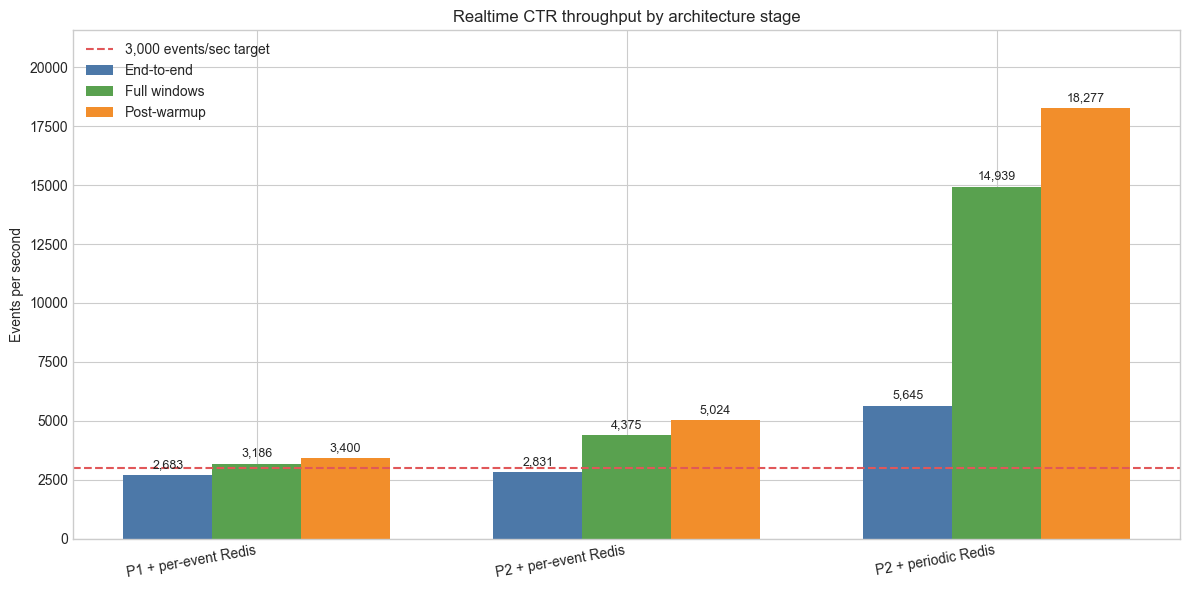

In [7]:
labels = summary["short_label"].tolist()
x = np.arange(len(labels))
width = 0.24
fig, ax = plt.subplots(figsize=(12, 6))
series = [
    ("End-to-end", "end_to_end_eps", "#4C78A8"),
    ("Full windows", "full_window_eps", "#59A14F"),
    ("Post-warmup", "post_warmup_eps", "#F28E2B"),
]
for index, (name, column, color) in enumerate(series):
    bars = ax.bar(x + (index - 1) * width, summary[column], width, label=name, color=color)
    ax.bar_label(bars, labels=[f"{value:,.0f}" for value in summary[column]], padding=3, fontsize=9)
ax.axhline(3_000, color="#E15759", linestyle="--", linewidth=1.5, label="3,000 events/sec target")
ax.set_ylabel("Events per second")
ax.set_title("Realtime CTR throughput by architecture stage")
ax.set_xticks(x, labels, rotation=10, ha="right")
ax.legend()
ax.set_ylim(0, summary[["end_to_end_eps", "full_window_eps", "post_warmup_eps"]].to_numpy().max() * 1.18)
plt.tight_layout()
plt.show()

In [8]:
baseline = summary.iloc[0]
speedups = summary[["short_label", "end_to_end_eps", "full_window_eps", "post_warmup_eps"]].copy()
for column in ("end_to_end_eps", "full_window_eps", "post_warmup_eps"):
    speedups[f"{column}_speedup"] = speedups[column] / baseline[column]
speedups[["short_label", "end_to_end_eps_speedup", "full_window_eps_speedup", "post_warmup_eps_speedup"]].style.format({
    "end_to_end_eps_speedup": "{:.2f}x",
    "full_window_eps_speedup": "{:.2f}x",
    "post_warmup_eps_speedup": "{:.2f}x",
})

,short_label,end_to_end_eps_speedup,full_window_eps_speedup,post_warmup_eps_speedup
stage,,,,
1. Initial baseline,P1 + per-event Redis,1.00x,1.00x,1.00x
2. Parallelism improvement,P2 + per-event Redis,1.06x,1.37x,1.48x
3. Periodic Redis flushing,P2 + periodic Redis,2.10x,4.69x,5.38x


## Processing windows

These timelines reveal startup cost, steady-state behavior, subtask balance, and trailing partial windows. Partial windows are shown with an `x` marker and should not be used as sustained-capacity measurements.

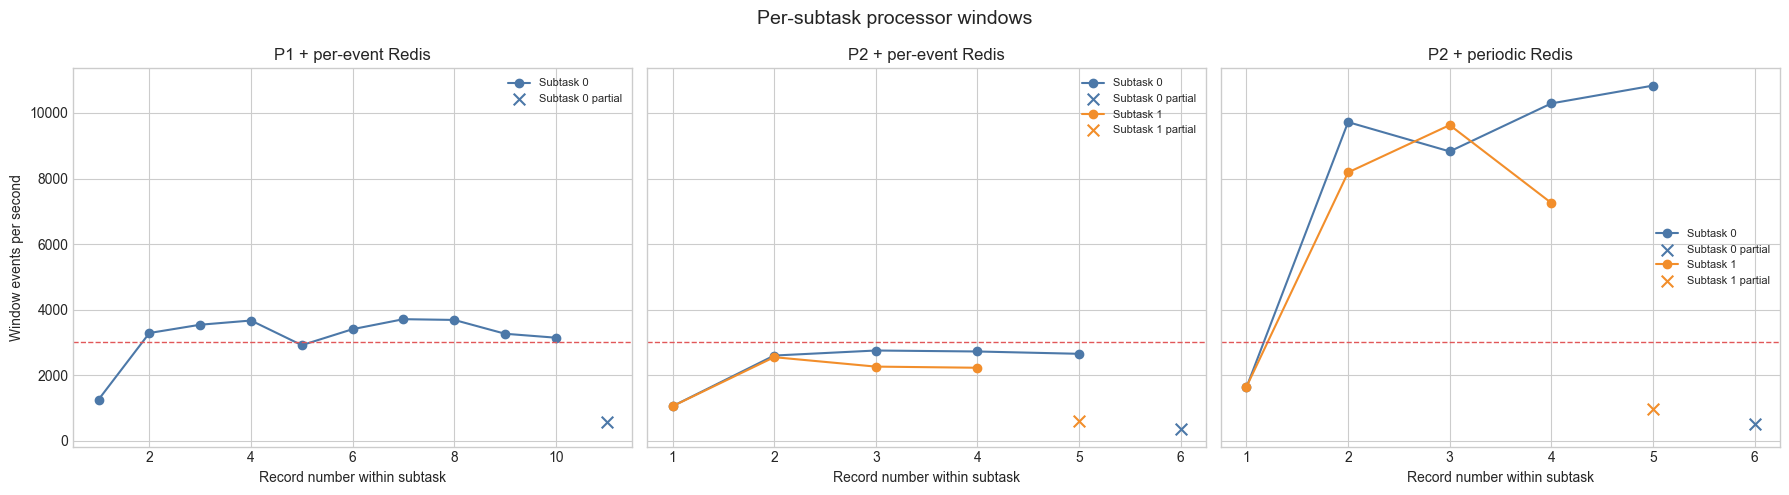

In [9]:
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(18, 5), sharey=True)
colors = ["#4C78A8", "#F28E2B", "#59A14F", "#E15759"]
for ax, experiment in zip(axes, EXPERIMENTS, strict=True):
    records = records_by_stage[experiment["stage"]]
    for color, (subtask_index, subtask) in zip(colors, records.groupby("subtask_index"), strict=False):
        max_window = subtask["window_events"].max()
        full = subtask["window_events"] == max_window
        ax.plot(subtask.loc[full, "record_index"], subtask.loc[full, "window_events_per_second"], marker="o", color=color, label=f"Subtask {subtask_index}")
        ax.scatter(subtask.loc[~full, "record_index"], subtask.loc[~full, "window_events_per_second"], marker="x", s=70, color=color, label=f"Subtask {subtask_index} partial")
    ax.axhline(3_000, color="#E15759", linestyle="--", linewidth=1)
    ax.set_title(experiment["short_label"])
    ax.set_xlabel("Record number within subtask")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Window events per second")
fig.suptitle("Per-subtask processor windows", fontsize=14)
plt.tight_layout()
plt.show()

## Redis write efficiency

Historical per-event runs did not emit flush counters. Their Redis flush count is reconstructed as one write per valid event, matching the implementation used at that time. The periodic-flush run uses recorded counters.

,short_label,valid_events,redis_flushes,redis_updates_flushed,redis_updates_coalesced,updates_per_redis_write,redis_write_reduction_pct,flush_metrics_source
stage,,,,,,,,
1. Initial baseline,P1 + per-event Redis,"50,997","50,997","50,997",0,1.0x,0.00%,Derived from historical per-event behavior
2. Parallelism improvement,P2 + per-event Redis,"50,997","50,997","50,997",0,1.0x,0.00%,Derived from historical per-event behavior
3. Periodic Redis flushing,P2 + periodic Redis,"50,997",414,"50,997","50,583",123.2x,99.19%,Recorded


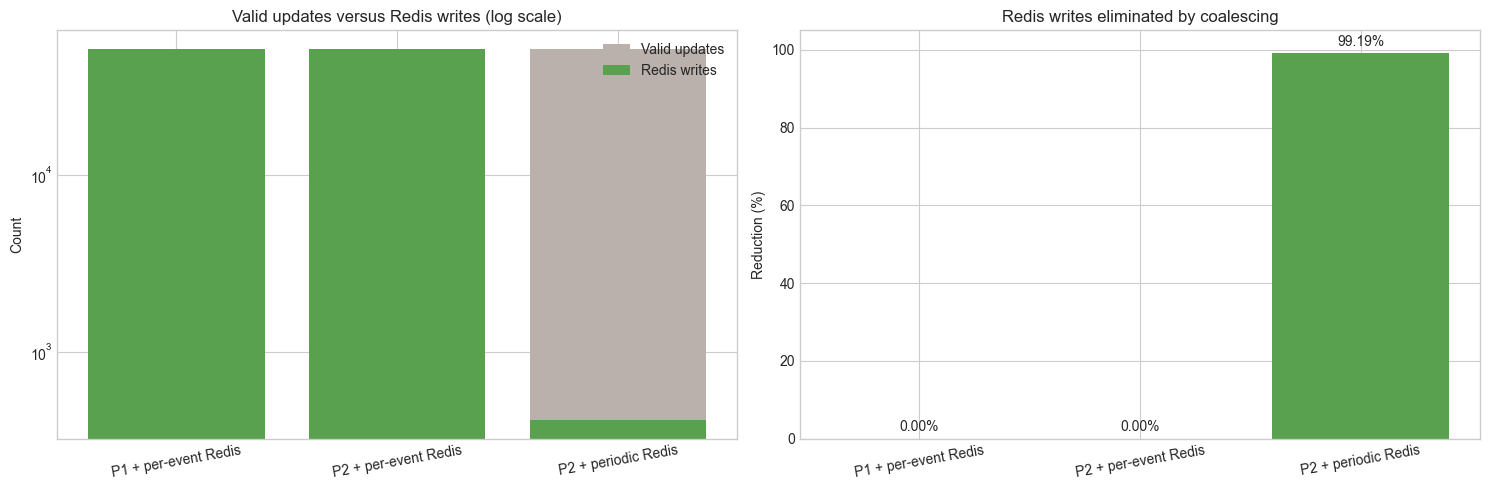

In [10]:
redis_table = summary[[
    "short_label",
    "valid_events",
    "redis_flushes",
    "redis_updates_flushed",
    "redis_updates_coalesced",
    "updates_per_redis_write",
    "redis_write_reduction_pct",
    "flush_metrics_source",
]].copy()
display(redis_table.style.format({
    "valid_events": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "redis_updates_flushed": "{:,.0f}",
    "redis_updates_coalesced": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(labels, summary["valid_events"], color="#BAB0AC", label="Valid updates")
axes[0].bar(labels, summary["redis_flushes"], color="#59A14F", label="Redis writes")
axes[0].set_yscale("log")
axes[0].set_title("Valid updates versus Redis writes (log scale)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=10)
axes[0].legend()
reduction_bars = axes[1].bar(labels, summary["redis_write_reduction_pct"], color=["#BAB0AC", "#BAB0AC", "#59A14F"])
axes[1].bar_label(reduction_bars, labels=[f"{value:.2f}%" for value in summary["redis_write_reduction_pct"]], padding=3)
axes[1].set_ylim(0, 105)
axes[1].set_title("Redis writes eliminated by coalescing")
axes[1].set_ylabel("Reduction (%)")
axes[1].tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

## Correctness and completeness

Performance gains are acceptable only when Kafka production, Flink processing, and Redis deltas reconcile.

In [11]:
correctness = summary[[
    "short_label",
    "produced_events",
    "processed_events",
    "dead_letters",
    "redis_impression_delta",
    "redis_click_delta",
    "redis_updates_flushed",
    "gates_passed",
]].copy()
correctness["all_events_processed"] = correctness["produced_events"] == correctness["processed_events"]
correctness["all_updates_flushed"] = correctness["processed_events"] == correctness["redis_updates_flushed"]
correctness["status"] = np.where(
    correctness[["all_events_processed", "all_updates_flushed", "gates_passed"]].all(axis=1) & (correctness["dead_letters"] == 0),
    "PASS",
    "CHECK",
)
correctness.style.format({
    "produced_events": "{:,.0f}",
    "processed_events": "{:,.0f}",
    "redis_impression_delta": "{:,.0f}",
    "redis_click_delta": "{:,.0f}",
    "redis_updates_flushed": "{:,.0f}",
})

,short_label,produced_events,processed_events,dead_letters,redis_impression_delta,redis_click_delta,redis_updates_flushed,gates_passed,all_events_processed,all_updates_flushed,status
stage,,,,,,,,,,,
1. Initial baseline,P1 + per-event Redis,"50,997","50,997",0,"50,000",997,"50,997",True,True,True,PASS
2. Parallelism improvement,P2 + per-event Redis,"50,997","50,997",0,"50,000",997,"50,997",True,True,True,PASS
3. Periodic Redis flushing,P2 + periodic Redis,"50,997","50,997",0,"50,000",997,"50,997",True,True,True,PASS


## Subtask distribution

Balanced final counts show whether Kafka partitions and `key_by` distribute the workload across available Flink subtasks.

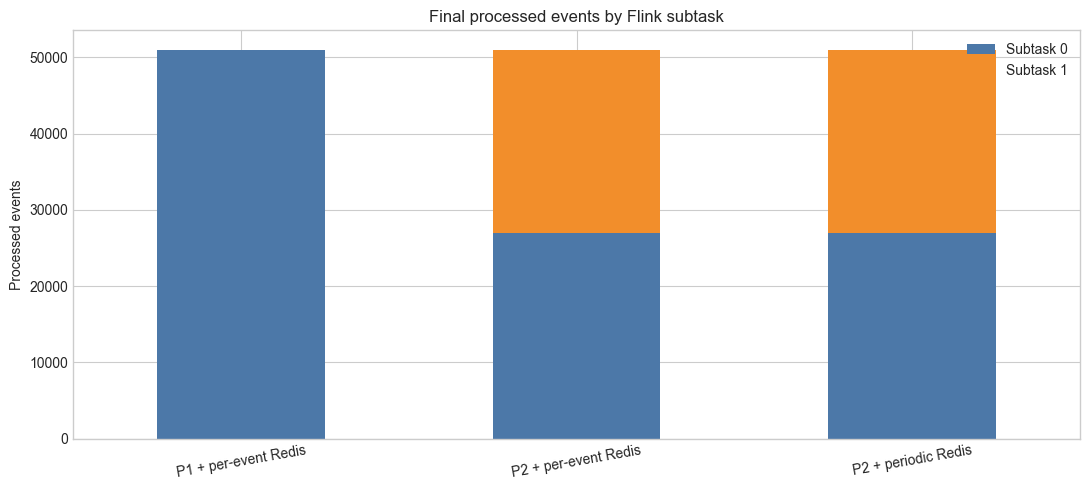

In [12]:
distribution_rows = []
for experiment in EXPERIMENTS:
    records = records_by_stage[experiment["stage"]]
    final_records = records.groupby("subtask_index", as_index=False).tail(1)
    for _, record in final_records.iterrows():
        distribution_rows.append({
            "short_label": experiment["short_label"],
            "subtask": f"Subtask {int(record['subtask_index'])}",
            "processed_events": int(record["processed_events"]),
        })
distribution = pd.DataFrame(distribution_rows).pivot(index="short_label", columns="subtask", values="processed_events").fillna(0)
ax = distribution.plot(kind="bar", stacked=True, figsize=(11, 5), color=["#4C78A8", "#F28E2B"])
ax.set_title("Final processed events by Flink subtask")
ax.set_xlabel("")
ax.set_ylabel("Processed events")
ax.tick_params(axis="x", rotation=10)
ax.legend(title="")
plt.tight_layout()
plt.show()

## Data-driven conclusions

In [13]:
initial = summary.iloc[0]
parallel = summary.iloc[1]
redis_optimized = summary.iloc[2]
display(Markdown(
    f"""
### What changed

- Increasing parallelism from 1 to 2 raised full-window throughput from **{initial['full_window_eps']:,.0f}** to **{parallel['full_window_eps']:,.0f} events/sec** (**{parallel['full_window_eps'] / initial['full_window_eps']:.2f}x**).
- Periodic Redis flushing then raised it to **{redis_optimized['full_window_eps']:,.0f} events/sec** (**{redis_optimized['full_window_eps'] / parallel['full_window_eps']:.2f}x** over parallelism alone).
- The final architecture is **{redis_optimized['full_window_eps'] / initial['full_window_eps']:.2f}x** faster than the initial active-window baseline.
- Redis writes fell from approximately **{int(parallel['redis_flushes']):,}** to **{int(redis_optimized['redis_flushes']):,}**, a **{redis_optimized['redis_write_reduction_pct']:.2f}%** reduction while all **{int(redis_optimized['processed_events']):,}** events remained accounted for.
- The final run averaged **{redis_optimized['updates_per_redis_write']:.1f} bucket updates per Redis write**.

### Interpretation

Parallelism improved capacity, but synchronous per-event Redis writes remained the dominant bottleneck. Keeping exact state in Flink and flushing only the latest dirty bucket snapshot removed that bottleneck without losing events or Redis totals.
"""
))


### What changed

- Increasing parallelism from 1 to 2 raised full-window throughput from **3,186** to **4,375 events/sec** (**1.37x**).
- Periodic Redis flushing then raised it to **14,939 events/sec** (**3.41x** over parallelism alone).
- The final architecture is **4.69x** faster than the initial active-window baseline.
- Redis writes fell from approximately **50,997** to **414**, a **99.19%** reduction while all **50,997** events remained accounted for.
- The final run averaged **123.2 bucket updates per Redis write**.

### Interpretation

Parallelism improved capacity, but synchronous per-event Redis writes remained the dominant bottleneck. Keeping exact state in Flink and flushing only the latest dirty bucket snapshot removed that bottleneck without losing events or Redis totals.


## Extending the history

For each new controlled experiment, add one entry to `EXPERIMENTS` with its artifact path, configured parallelism, and Redis strategy. Keep workload size, random seed, topics, and machine environment unchanged when comparing one optimization.

Because the optimized job consumes 50,000 events quickly, future scalability runs should use at least 200,000 events to create more steady-state full windows.